# Optimización con PSO usando PySwarms

Este notebook desarrolla una adaptación del **Proyecto 16: Wrapper feature selection con PSO (PySwarms)**. Mientras que el problema original plantea el uso de *Particle Swarm Optimization* (PSO) a través de la librería PySwarms como estrategia de búsqueda para la selección de atributos, en esta implementación práctica se ha redirigido la potencia de PSO para la **optimización de los hiperparámetros (p, d, q) de un modelo de series temporales ARIMA**.

El objetivo central es predecir los retornos financieros semanales de activos del mercado (como el SPY). Para ello, cada partícula del enjambre representa una combinación de parámetros ARIMA, los cuales son evaluados minimizando una función de *fitness* compuesta por el error cuadrático medio (RMSE), la precisión direccional y una penalización por complejidad del modelo. El marco de trabajo incluye:
* Un esquema de evaluación temporal mediante ventanas deslizantes (*rolling window*) de entrenamiento y validación.
* La ejecución periódica del algoritmo de optimización global de PySwarms para adaptar dinámicamente los hiperparámetros a los cambios de tendencia y volatilidad del mercado.
* Una evaluación final del rendimiento que contrasta el enfoque tradicional pasivo (*Buy and Hold*) frente a diversas estrategias activas de *trading* algorítmico basadas en las predicciones obtenidas.

In [47]:
import yfinance
import numpy
import statsmodels.tsa.arima.model
import sklearn
import pandas
import matplotlib.pyplot
import pyswarms
import warnings
import os
import json

warnings.filterwarnings("ignore")

Se define primero una función para descargar datos a traves de Yahoo finance. Utilizaremos directamente los intervalos semanales para eliminar el ruido producto de las operaciones diarias.

In [48]:
def download_data(ticker, start_date, end_date):
    data = yfinance.download(ticker, start=start_date, end=end_date, progress=False, interval="1wk", auto_adjust=False)
    return data

Definimos una lista de tickers sobre los que queremos trabajar y descargaremos los datos correspondientes. Para obtener resultados relevantes, se utilizaran datos a partir del año 2014, donde se empieza un periodo de crecimiento más estable en el mercado de forma general.

In [49]:
TICKERS = ["SPY"]
START = "2014-01-01"
END = "2025-12-31"

data = {}
for ticker in TICKERS:
    data[ticker] = download_data(ticker, START, END)

Para el modelo ARIMA, solo se requiere una serie temporal que permita predecir valores futuros. Como valores para dicha serie, utilizaremos el porcentaje de cambio semanal de precio de cierre ajustado. Eliminando efectos no deseados derivados tanto de la escala de valores de los precios de mercado como de la escala de valores muy pequeños de los retornos semanales, que podrían desestabilizar el proceso de optimización. Esto es necesario ya que los modelos ARIMA requieren de que la serie temporal sea estacionaria, es decir, con media y varianza constantes a lo largo del tiempo, por lo que usar valores porcentuales nos hace cumplir este requisito.

In [50]:
def compute_returns(df):
    df["Return"] = df["Adj Close"].pct_change() * 100
    df.dropna(inplace=True)
    returns = df["Return"].values
    fechas = df.index.values
    return {"fechas": fechas, "returns": returns}

Para cada uno de nuestros tickers, aplicamos la función de cálculo de retornos a los datos descargados, obteniendo así las series temporales que utilizaremos para el entrenamiento y evaluación de nuestro modelo ARIMA.

In [51]:
for ticker, df in data.items():
    data[ticker] = compute_returns(df)

Se alamcenan los datos en disco por si queremos reutilizarlos posteriormente sin necesidad de volver a descargarlos, lo que puede ser útil para acelerar el proceso de desarrollo y pruebas del modelo.

In [52]:
ROOT_DIR = ".."
DATA_DIR = os.path.join(ROOT_DIR, "data")

def store_data(ticker, data):
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(os.path.join(DATA_DIR, ticker), exist_ok=True)
    filename = f"returns.csv"
    filepath = os.path.join(DATA_DIR, ticker, filename)
    df = pandas.DataFrame(data, columns=["Date", "Return"])
    df.to_csv(filepath, index=False)

def load_data(ticker):
    filepath = os.path.join(DATA_DIR, ticker, "returns.csv")
    df = pandas.read_csv(filepath, parse_dates=["Date"])
    fechas = df["Date"].values
    returns = df["Return"].values
    return {"fechas": fechas, "returns": returns}

Almacenarmos y recargamos los datos.

In [53]:
for ticker, data_dict in data.items():
    store_data(ticker, list(zip(data_dict["fechas"], data_dict["returns"])))

for ticker in TICKERS:
    data[ticker] = load_data(ticker)

Un modelo ARIMA se define por tres parámetros enteros: p, d y q. El parámetro p representa el orden de la parte autorregresiva del modelo, es decir, el número de valores pasados que se utilizan para predecir el valor actual. El parámetro d representa el grado de diferenciación necesario para hacer que la serie temporal sea estacionaria, es decir, el número de veces que se deben restar los valores pasados para eliminar tendencias o estacionalidades. El parámetro q representa el orden de la parte de media móvil del modelo, es decir, el número de errores pasados que se utilizan para predecir el valor actual. 

Definimos una funcion de fitness que recibe estos parámetros de ARIMA, junto con las series de entrenamiento y validación, y devuelve una medida de desempeño del modelo ARIMA con esos parámetros. La función de fitness se basa en el error cuadrático medio (RMSE) entre las predicciones del modelo y los valores reales de la serie de validación, la precisión direccional (la proporción de predicciones que aciertan la dirección del cambio) y una penalización por complejidad basada en la suma de los parámetros p y q. El objetivo es minimizar esta función de fitness para encontrar los mejores parámetros de ARIMA para nuestras series temporales.

In [54]:
def fitness_arima(arima_params, train_data, val_data):
    p, d, q = int(round(arima_params[0])), int(round(arima_params[1])), int(round(arima_params[2]))
    model = statsmodels.tsa.arima.model.ARIMA(train_data, order=(p, d, q))
    model.initialize_approximate_diffuse()
    model = model.fit()
    forecast = model.forecast(steps=len(val_data))
    rmse = numpy.sqrt(sklearn.metrics.mean_squared_error(val_data, forecast))
    correct_directions = numpy.sum(numpy.sign(forecast) == numpy.sign(val_data))
    directional_accuracy = correct_directions / len(val_data)
    complexity_penalty = 0.05 * (p + q)
    fitness = rmse + (1.5 - directional_accuracy) + complexity_penalty
    return fitness

Ahora, definimos una función wrapper para la función de fitness, que se encargará de recibir un array de parámetros de ARIMA para cada partícula en el enjambre, y devolver un array de scores correspondientes a cada partícula. Esta función será utilizada por el algoritmo PSO para evaluar el desempeño de cada conjunto de parámetros de ARIMA durante el proceso de optimización.

In [55]:
def swarm_fitness_wrapper(arima_params_arr, train_data, val_data):
    # arima_params_arr es un array de forma (n_particles x (p, d, q))
    n_particles = arima_params_arr.shape[0]
    scores = numpy.zeros(n_particles)
    for i in range(n_particles):
        scores[i] = fitness_arima(arima_params_arr[i], train_data, val_data)
    return scores

La función de ejecución del modelo ARIMA con PSO realizará el siguiente proceso.
* Division de la serie temporal en ventanas de entrenamiento y validación. Cada ventana se desplazará a lo largo de la serie temporal, permitiendo evaluar el modelo en diferentes periodos de tiempo. La ventana de entrenamiento se corresponde con 4 años (208 semanas) de datos de retornos; mientras la ventana de validación con las 4 semanas de datos de retornos posteriores a la ventana de entrenamiento.
* Observando la naturaleza de los datos y tamaño de la ventana de validación, se limita la ejecución de PSO a 1 vez por mes. Esto se debe a que no se espera que los retornos tengan cambios muy drásticos entre semanas dentro de un mismo mes, por lo que los parámetros ARIMA no deberían alterarse significativamente entre semanas. Esto también ayuda a reducir el tiempo de ejecución del modelo, ya que la optimización de los parámetros de ARIMA puede ser costosa computacionalmente.
* Para cada ventana de entrenamiento y validación, si la semana es multiplo de 4, se ejecuta el algoritmo PSO para optimizar los parámetros de ARIMA. El mejor conjunto de parámetros encontrado se utiliza para entrenar un modelo ARIMA con la ventana de entrenamiento, y luego se realiza una predicción para la siguiente semana. Esta predicción se almacena junto con el valor real de la siguiente semana para su posterior evaluación. 

Distingase entre las ventanas de validacón usadas para PSO y para las predicciones reales. En PSO, usamos para validar las siguientes 4 semanas, obteniendo los mejores hiperparámetros de ARIMA para las próximas 4 semanas. Sin embargo, para las predicciones reales, solo se predice la siguiente semana, desplazando la ventana de entrenamiento una semana cada vez, y usando los mismos hiperparámetros de ARIMA obtenidos para las próximas 4 semanas. Esto se hace para simular un escenario más realista, donde no se tendría acceso a los datos futuros para validar el modelo, y se espera que los hiperparámetros de ARIMA se mantengan relativamente estables durante un periodo de 4 semanas.

In [56]:
# 4 años de ventana de datos semanales.
WINDOW_SIZE = 208
# 4 semanas de validación.
VALIDATION_SIZE = 4

# Opciones para el algoritmo PSO.
SWARM_OPTIONS = { 'c1': 1.5, 'c2': 1.5, 'w': 0.7 }
BOUNDS = (numpy.array([0, 0, 0]), numpy.array([5, 1, 5]))
N_PARTICLES = 10
DIMENSIONS = 3
ITERATIONS = 20

def execute_arima_pso(data):
    predictions = []
    actual_values = []
    model_history = []
    cost_history = []
    pso_cost_history = []
    pso_run_indices = []

    best_pdq = None

    for t in range(WINDOW_SIZE, len(data) - 1):
        current_window = data[t - WINDOW_SIZE:t]
        train_data = current_window[:-VALIDATION_SIZE]
        val_data = current_window[-VALIDATION_SIZE:]

        if t % 4 == 0 or best_pdq is None:
            initial_positions = numpy.random.uniform(low=BOUNDS[0], high=BOUNDS[1], size=(N_PARTICLES, DIMENSIONS))
            if best_pdq is not None:
                initial_positions[0] = best_pdq
            
            optimizer = pyswarms.single.GlobalBestPSO(n_particles=N_PARTICLES, dimensions=DIMENSIONS, options=SWARM_OPTIONS, bounds=BOUNDS, init_pos=initial_positions)
            cost, pos = optimizer.optimize(swarm_fitness_wrapper, iters=ITERATIONS, train_data=train_data, val_data=val_data, verbose=False)
            best_pdq = [int(round(pos[0])), int(round(pos[1])), int(round(pos[2]))]
            pso_cost_history.append(list(optimizer.cost_history))
            pso_run_indices.append(t)
        
        final_model = statsmodels.tsa.arima.model.ARIMA(current_window, order=best_pdq).fit()
        next_pred = final_model.forecast(steps=1)[0]
        
        predictions.append(next_pred)
        actual_values.append(data[t])
        model_history.append(best_pdq)
        cost_history.append(cost)
    
    return {"predictions": predictions, "actual_values": actual_values, "model_history": model_history, "cost_history": cost_history, "pso_cost_history": pso_cost_history, "pso_run_indices": pso_run_indices}

Para cada uno de nuestros tickers, ejecutamos la función de ejecución del modelo ARIMA con PSO, obteniendo así las predicciones, valores reales, historia de modelos y costos para cada ticker.

In [57]:
results = {}
for ticker, dict_data in data.items():
    results[ticker] = execute_arima_pso(dict_data['returns'])

Se guardan los resultados en disco para evitar perderlos.

In [58]:
ROOT_DIR = ".."
RESULTS_DIR = os.path.join(ROOT_DIR, "results")

def store_results(ticker, results):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    os.makedirs(os.path.join(RESULTS_DIR, ticker), exist_ok=True)
    filename = f"results.json"
    filepath = os.path.join(RESULTS_DIR, ticker, filename)
    with open(filepath, "w") as f:
        json.dump(results, f)

def load_results(ticker):
    filepath = os.path.join(RESULTS_DIR, ticker, "results.json")
    with open(filepath, "r") as f:
        results = json.load(f)
    return results

In [59]:
for ticker, results_dict in results.items():
    store_results(ticker, results_dict)

In [60]:
for ticker in TICKERS:
    results[ticker] = load_results(ticker)

Haremos una visualización de los resultados obtenidos. La siguiente función implementa y visualiza una comparativa cuantitativa entre la estrategia pasiva de Comprar y Mantener y tres variantes activas basadas en las predicciones semanales del modelo: la estrategia base Largo/Corto (que toma posiciones completas ante cualquier señal, lo que a menudo significa operar con "ruido" del mercado), una estrategia de Largo/Corto con umbral (que exige un nivel mínimo de convicción o movimiento esperado para entrar al mercado, refugiándose en liquidez para evitar operaciones falsas), y una versión Solo Largos (Long Only) (que aprovecha las predicciones positivas pero pasa a efectivo ante las negativas, eliminando el riesgo severo de ir en corto durante mercados alcistas). Para evaluar estos enfoques de manera realista, la gráfica se divide en dos paneles interconectados; el panel principal ilustra la curva de retorno acumulado e incorpora métricas clave de rendimiento ajustado al riesgo directamente en la leyenda (el Ratio de Sharpe anualizado y el Retorno Final), mientras que el panel inferior mapea dinámicamente los Drawdowns (las caídas porcentuales desde los máximos históricos de la cuenta), permitiéndote medir no solo cuánta rentabilidad genera cada estrategia, sino también el riesgo real y el nivel de estrés financiero que habría que soportar durante las rachas perdedoras.

In [61]:
def plot_advanced_strategy_performance(ticker, data, results, threshold=0.005):
    fechas = pandas.to_datetime(data['fechas'][WINDOW_SIZE + 1:len(data['returns'])])    
    preds_arr = numpy.array(results['predictions']) / 100.0
    actual_arr = numpy.array(results['actual_values']) / 100.0
    
    # Benchmark: Comprar y mantener.
    ret_bh = actual_arr
    
    # Strategia A: Long/Short base.
    pos_base = numpy.sign(preds_arr)
    ret_base = pos_base * actual_arr
    
    # Strategia B: Long/Short con filtro de convicción.
    pos_thresh = numpy.where(numpy.abs(preds_arr) > threshold, numpy.sign(preds_arr), 0)
    ret_thresh = pos_thresh * actual_arr
    
    # Strategia C: Sólo Long.
    pos_long_only = numpy.where(preds_arr > 0, 1, 0)
    ret_long = pos_long_only * actual_arr
    
    strategies = {
        'Comprar y Mantener': ret_bh,
        'Base L/S': ret_base,
        f'Filtro de Convicción L/S (>{threshold*100}%)': ret_thresh,
        'Sólo Long': ret_long
    }
    
    cum_returns = {}
    drawdowns = {}
    stats_labels = {}
    
    for name, ret in strategies.items():
        # Retorno acumulado.
        cum = numpy.cumprod(1 + ret) - 1
        cum_returns[name] = cum
        
        # Drawdown.
        roll_max = numpy.maximum.accumulate(cum + 1)
        dd = (cum + 1 - roll_max) / roll_max
        drawdowns[name] = dd
        
        # Métricas de rendimiento.
        ann_return = numpy.mean(ret) * 52
        ann_vol = numpy.std(ret) * numpy.sqrt(52)
        sharpe = ann_return / ann_vol if ann_vol > 0 else 0
        max_dd = numpy.min(dd)
        
        stats_labels[name] = f"{name} (Ret: {cum[-1]*100:.1f}%, Sharpe: {sharpe:.2f}, MDD: {max_dd*100:.1f}%)"
    
    fig, (ax1, ax2) = matplotlib.pyplot.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    colors = ['gray', 'blue', 'purple', 'green']
    
    for i, (name, cum) in enumerate(cum_returns.items()):
        linewidth = 1.5 if i == 0 else 2  # Make strategies slightly thicker than benchmark
        ax1.plot(fechas, cum * 100, label=stats_labels[name], color=colors[i], linewidth=linewidth)
        
    ax1.set_title(f'{ticker} - Rendimiento de las estrategias (Intersemanal)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Retorno acumulado (%)', fontsize=12)
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    for i, (name, dd) in enumerate(drawdowns.items()):
        ax2.fill_between(fechas, dd * 100, 0, alpha=0.2, color=colors[i])
        ax2.plot(fechas, dd * 100, color=colors[i], linewidth=1)
        
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

De la gráfica siguiente, se puede observar una característica principal: a mediados de 2022, se empeora significativamente el rendimiento de la estrategia, lo que se corresponde con un periodo de alta volatilidad e incertidumbre en los mercados financieros a nivel global. Esto sugiere que el modelo ARIMA con PSO puede tener dificultades para adaptarse rápidamente a cambios bruscos en las condiciones del mercado, lo que es una limitación importante a tener en cuenta al utilizar este enfoque para la predicción de retornos financieros.

Respecto a la utilidad real, se observa que las estrategias basadas en este modelo pueden llegar a generar retornos positivos mayores a la estrategia pasiva de Comprar y Mantener, especialmente en periodos de mercado relativamente estables. Sin embargo, también se observa que estas estrategias pueden sufrir drawdowns significativos durante periodos de alta volatilidad, lo que puede resultar en pérdidas importantes para los inversores. Véase como las estrategias que permiten operar en Corto tienden a sufrir drawdowns más severos durante estos periodos, encontrando que a partir de 2022, la estrategia Solo Largos (Long Only) muestra un rendimiento relativamente mejor, lo que sugiere que puede ser una opción más segura para los inversores que buscan aprovechar las predicciones del modelo sin asumir el riesgo adicional de operar en Corto durante periodos de alta volatilidad.

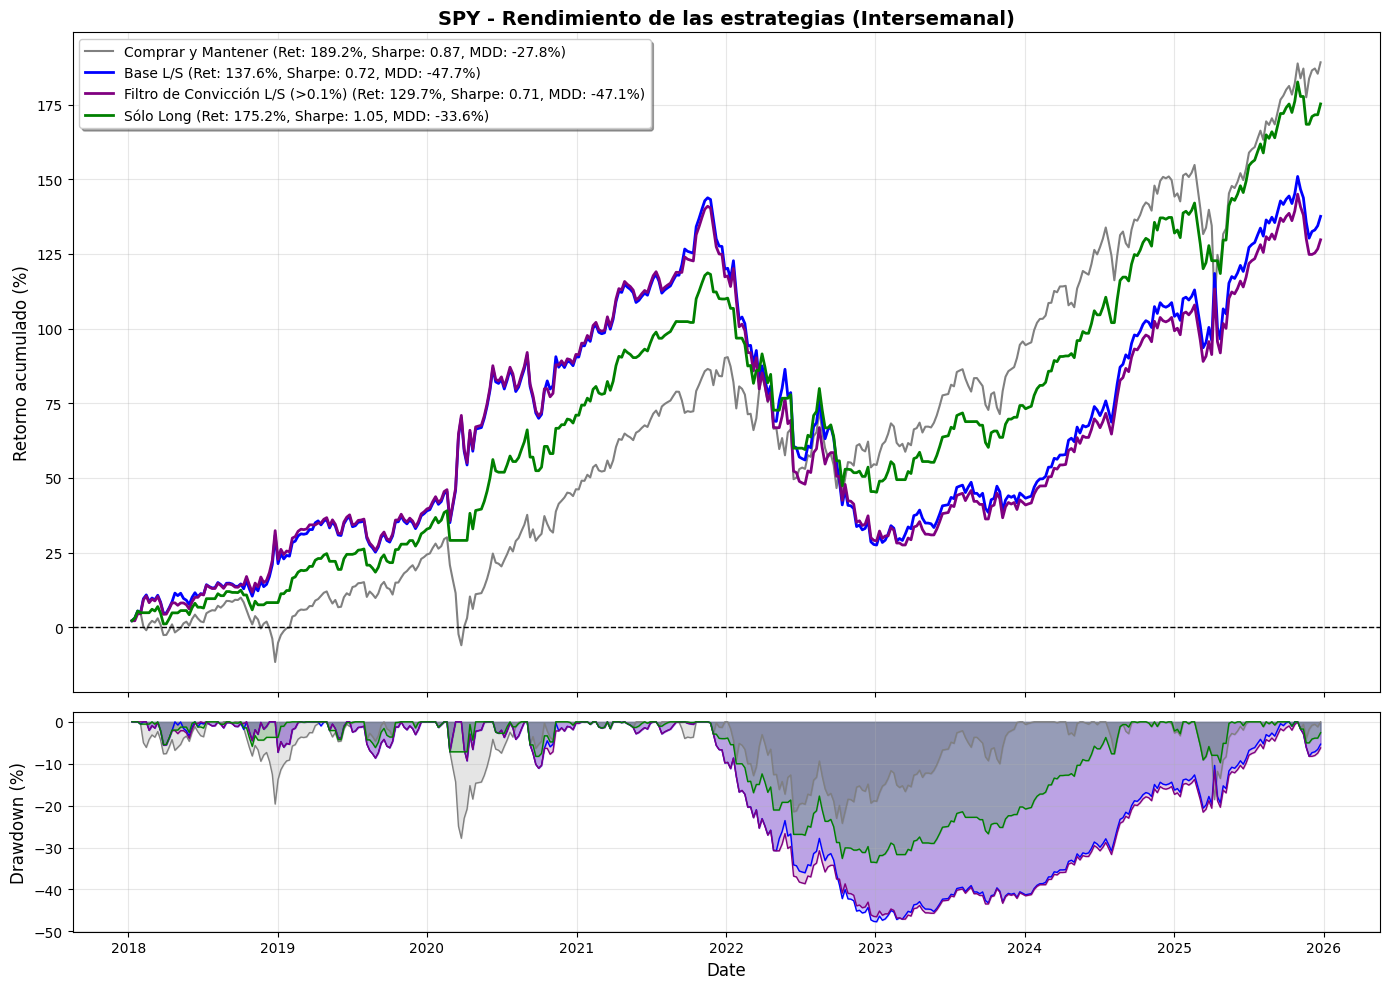

In [62]:
for ticker in TICKERS:
    plot_advanced_strategy_performance(ticker, data[ticker], results[ticker], threshold=0.001)

También es interesante observar como PSO va ajustando a lo largo del tiempo los hiperparámetros de ARIMA, lo que se refleja en la evolución de los parámetros p, d y q a lo largo de las semanas. Esto sugiere que el modelo está intentando adaptarse a los cambios en la serie temporal, aunque como se mencionó anteriormente, puede tener dificultades para adaptarse rápidamente a cambios bruscos en las condiciones del mercado devido a la linealidad del modelo ARIMA y la naturaleza no lineal de los mercados financieros, especialmente durante periodos de alta volatilidad.

In [63]:
def plot_pso_adjustment(ticker, data, results):
    fechas = data['fechas']
    returns = data['returns']
    model_history = results['model_history']

    test_dates = fechas[WINDOW_SIZE + 1:len(returns)]

    df_history = pandas.DataFrame(model_history, columns=['p', 'd', 'q'], index=test_dates)

    fig, axes = matplotlib.pyplot.subplots(3, 1, figsize=(12, 8), sharex=True)
    colores = ['blue', 'orange', 'green']
    for i, col in enumerate(df_history.columns):
        axes[i].step(df_history.index, df_history[col], where='post', color=colores[i], linewidth=2)
        axes[i].set_ylabel(col, fontsize=12)
        axes[i].set_yticks(range(0, 6))
        axes[i].grid(True, alpha=0.3)
    matplotlib.pyplot.suptitle('Evolución de Parámetros ARIMA', fontsize=14)
    matplotlib.pyplot.xlabel('Fecha', fontsize=12)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

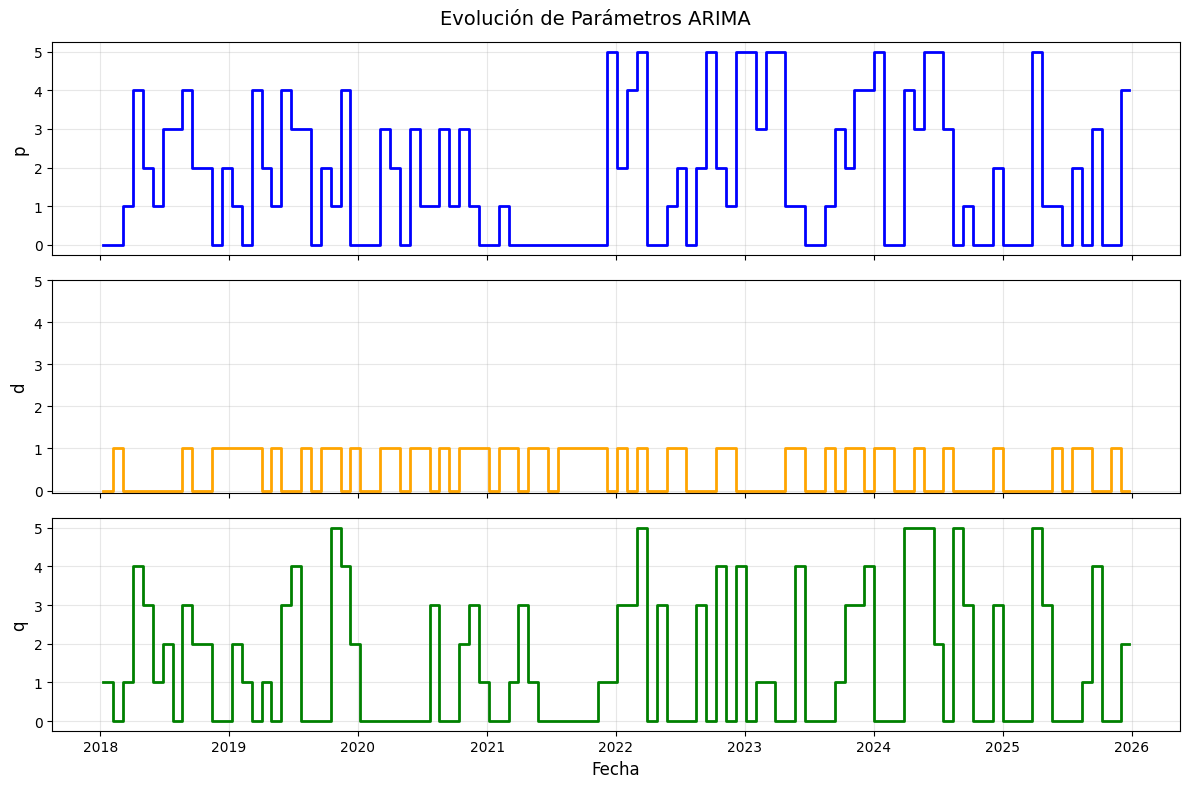

In [64]:
for ticker in TICKERS:
    plot_pso_adjustment(ticker, data[ticker], results[ticker])

Experimentalmente, es útil observar como nuestro modelo y metodología logran estar por encima de la barrera del 50% en la predicción de la dirección del mercado, lo que sugiere que el modelo tiene cierta capacidad para capturar patrones en la serie temporal que son relevantes para predecir la dirección de los retornos. Véase como durante periodos de baja volatilidad, existen picos de precisión direccional que superan el 90%, dandonos una muy buena señal del mercado subyacente. Lo contrario ocurre durante periodos de alta volatilidad.

In [65]:
def plot_rolling_hit_rate(ticker, data, results):
    fechas = data['fechas']
    returns = data['returns']
    predictions = results['predictions']
    actual_values = results['actual_values']

    test_dates = fechas[WINDOW_SIZE + 1:len(returns)]
    preds_arr = numpy.array(predictions) / 100
    actual_arr = numpy.array(actual_values) / 100

    aciertos = (numpy.sign(preds_arr) == numpy.sign(actual_arr)).astype(int)
    rolling_hit_rate = pandas.Series(aciertos, index=test_dates).rolling(window=12).mean() * 100

    matplotlib.pyplot.figure(figsize=(12, 5))
    matplotlib.pyplot.plot(test_dates, rolling_hit_rate, color='purple', linewidth=2)
    matplotlib.pyplot.axhline(50, color='red', linestyle='--', linewidth=1, label='Línea de aleatoriedad')
    matplotlib.pyplot.axhline(rolling_hit_rate.mean(), color='green', linestyle='-.', linewidth=1, label=f'Hit Rate Promedio: {rolling_hit_rate.mean():.2f}%')
    matplotlib.pyplot.title('Hit Rate de la Estrategia (Rolling 12 Semanas)', fontsize=14)
    matplotlib.pyplot.xlabel('Fecha', fontsize=12)
    matplotlib.pyplot.ylabel('Hit Rate (%)', fontsize=12)
    matplotlib.pyplot.legend()
    matplotlib.pyplot.grid(True, alpha=0.3)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

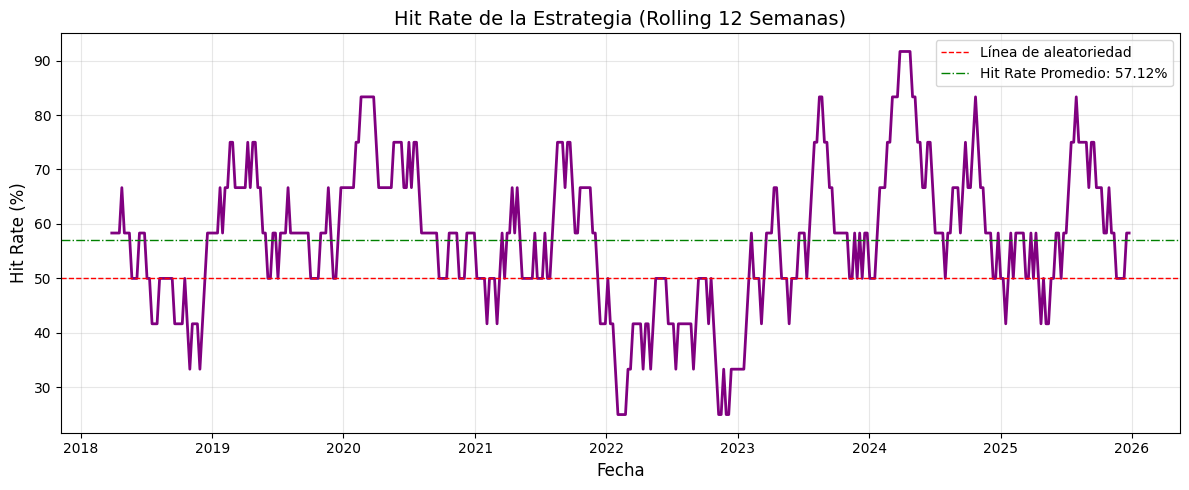

In [66]:
for ticker in TICKERS:
    plot_rolling_hit_rate(ticker, data[ticker], results[ticker])

In [67]:
def plot_prediction_matrix(ticker, data, results):
    predictions = results['predictions']
    actual_values = results['actual_values']
    preds_arr = numpy.array(predictions) / 100
    actual_arr = numpy.array(actual_values) / 100

    aciertos = (numpy.sign(preds_arr) == numpy.sign(actual_arr)).astype(int)

    matplotlib.pyplot.figure(figsize=(12, 8))
    colores_puntos = ['green' if a == 1 else 'red' for a in aciertos]
    matplotlib.pyplot.scatter(preds_arr*100, actual_arr*100, c=colores_puntos, alpha=0.6, edgecolors='k')
    matplotlib.pyplot.axhline(0, color='gray', linestyle='--', linewidth=1)
    matplotlib.pyplot.axvline(0, color='gray', linestyle='--', linewidth=1)
    matplotlib.pyplot.text(numpy.max(preds_arr)*100*0.7, numpy.max(actual_arr)*100*0.7, 'Aciertos Long\n(+/+)', color='green', fontsize=10, ha='center')
    matplotlib.pyplot.text(numpy.min(preds_arr)*100*0.7, numpy.min(actual_arr)*100*0.7, 'Aciertos Short\n(-/-)', color='green', fontsize=10, ha='center')
    matplotlib.pyplot.text(numpy.max(preds_arr)*100*0.7, numpy.min(actual_arr)*100*0.7, 'Errores Long\n(+/-)', color='red', fontsize=10, ha='center')
    matplotlib.pyplot.text(numpy.min(preds_arr)*100*0.7, numpy.max(actual_arr)*100*0.7, 'Errores Short\n(-/+)', color='red', fontsize=10, ha='center')
    matplotlib.pyplot.title('Predicciones vs Realidad', fontsize=14)
    matplotlib.pyplot.xlabel('Predicción (%)', fontsize=12)
    matplotlib.pyplot.ylabel('Retorno Real (%)', fontsize=12)
    matplotlib.pyplot.grid(True, alpha=0.3)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

Por últmo, a modo informativo, se muestra una gráfica de dispersión que compara las predicciones del modelo con los valores reales de los retornos semanales. En esta gráfica, cada punto representa una predicción y su valor real correspondiente, con puntos verdes indicando aciertos en la dirección del cambio (predicción y valor real tienen el mismo signo) y puntos rojos indicando errores (predicción y valor real tienen signos opuestos). Esta visualización nos permite evaluar de manera intuitiva la capacidad del modelo para predecir no solo la magnitud sino también la dirección de los cambios en los retornos, lo cual es crucial para la toma de decisiones en estrategias de trading basadas en estas predicciones.

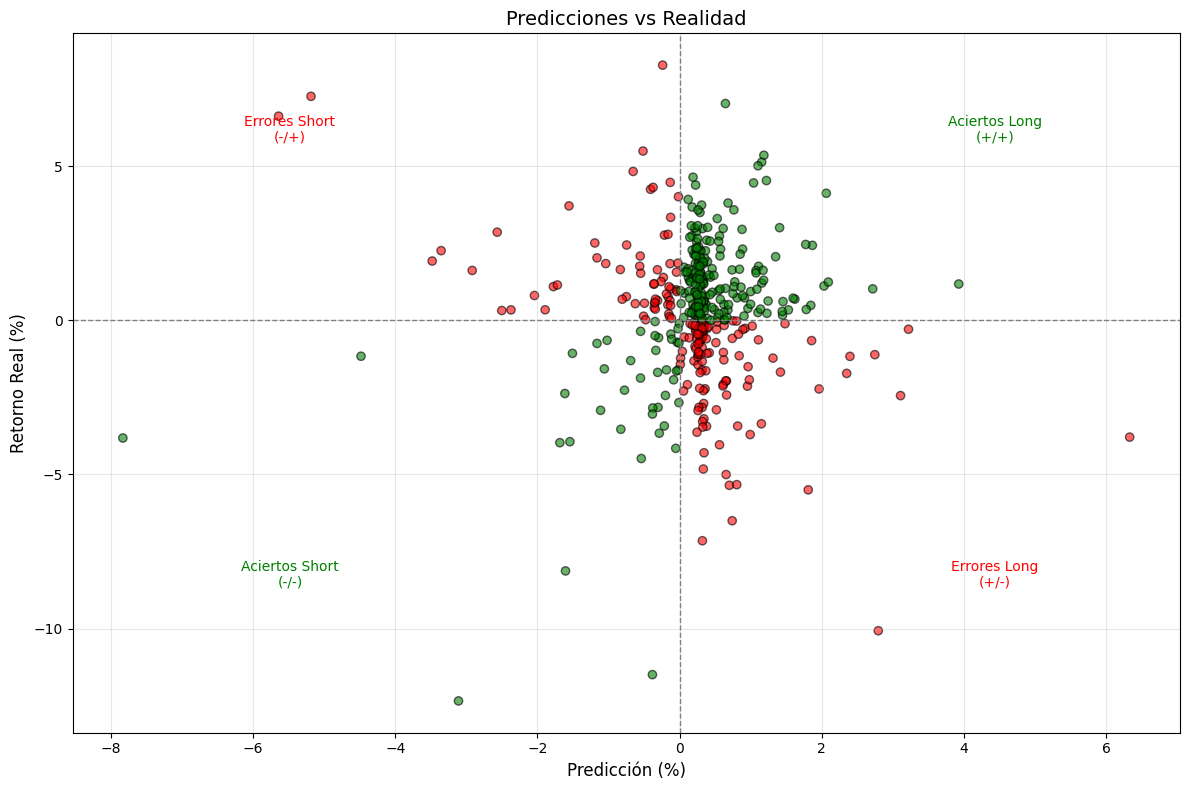

In [68]:
for ticker in TICKERS:
    plot_prediction_matrix(ticker, data[ticker], results[ticker])

Es interesante también observar como evoluciona el valor de fitness entre las iteraciones del algoritmo PSO y la ejecución de las ventanas a lo largo del tiempo. Se pueden observar como, entre semanas diferentes, cuando las condiciones del mercado se recrudecen, el valor de fitness tiende a aumentar, lo que indica que el modelo tiene más dificultades para encontrar parámetros de ARIMA que se ajusten bien a la serie temporal durante estos periodos.

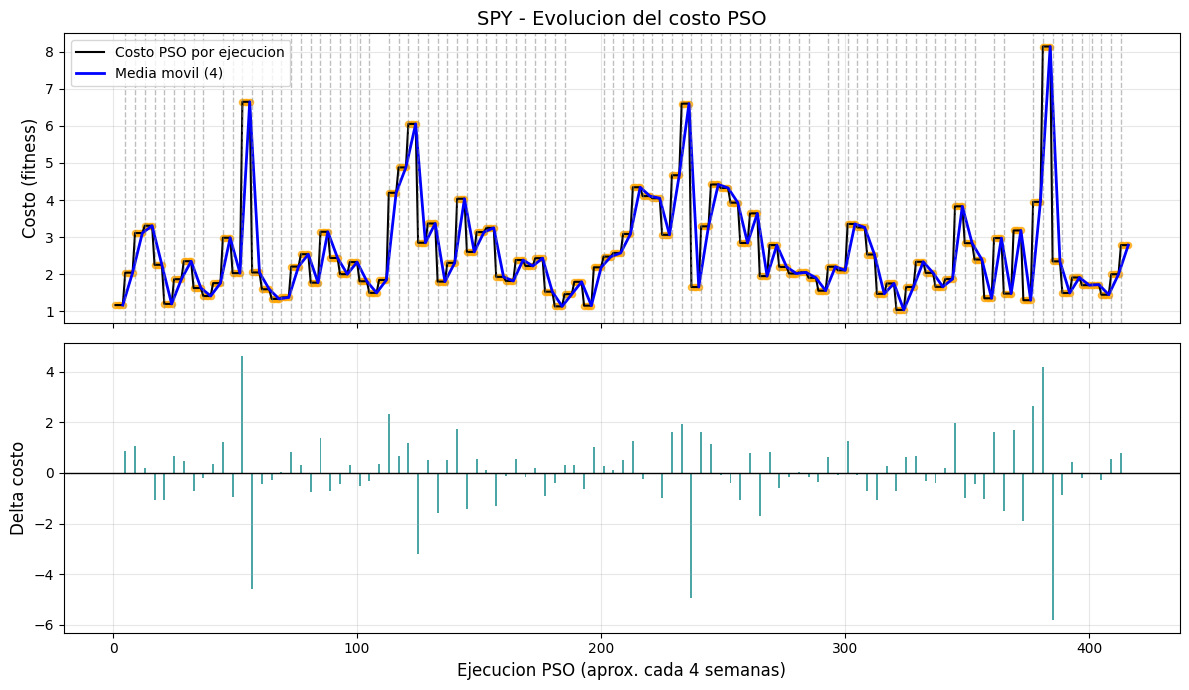

In [69]:
def plot_pso_cost_history(ticker, results, smooth_window=4):
    cost_history = results.get("cost_history", [])
    model_history = results.get("model_history", [])
    runs = numpy.arange(1, len(cost_history) + 1)
    costs = numpy.array(cost_history, dtype=float)
    deltas = numpy.diff(costs, prepend=costs[0])

    # Indices where PSO picked a new (p, d, q).
    change_points = []
    if len(model_history) > 0:
        prev = tuple(model_history[0])
        for i, pdq in enumerate(model_history[1:], start=1):
            cur = tuple(pdq)
            if cur != prev:
                change_points.append(i + 1)
                prev = cur

    fig, (ax1, ax2) = matplotlib.pyplot.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax1.plot(runs, costs, color="black", linewidth=1.5, label="Costo PSO por ejecucion")
    ax1.scatter(runs, costs, color="orange", s=20, alpha=0.7)

    if len(costs) >= smooth_window:
        smooth = pandas.Series(costs).rolling(window=smooth_window).mean()
        ax1.plot(runs, smooth, color="blue", linewidth=2, label=f"Media movil ({smooth_window})")

    for cp in change_points:
        ax1.axvline(cp, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax1.set_title(f"{ticker} - Evolucion del costo PSO", fontsize=14)
    ax1.set_ylabel("Costo (fitness)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.bar(runs, deltas, color="teal", alpha=0.7)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_xlabel("Ejecucion PSO (aprox. cada 4 semanas)", fontsize=12)
    ax2.set_ylabel("Delta costo", fontsize=12)
    ax2.grid(True, alpha=0.3)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

for ticker in TICKERS:
    plot_pso_cost_history(ticker, results[ticker])

La celda a continuación permite explorar la evolución de costos dentro de la ejecución de PSO. Dado que siempre se parte de los valores de la semana anterior, y se optimiza de forma iterativa. No se espera que haya variaciones significativas entre semanas, lo que implica una gráfica mayormente plana. La excepción a esto ocurre durante periodos de alta volatilidad, donde el modelo tiene más dificultades para encontrar parámetros de ARIMA que se ajusten bien a la serie temporal, lo que se refleja en un aumento del valor de fitness y una mayor variabilidad en los costos durante las iteraciones del algoritmo PSO.

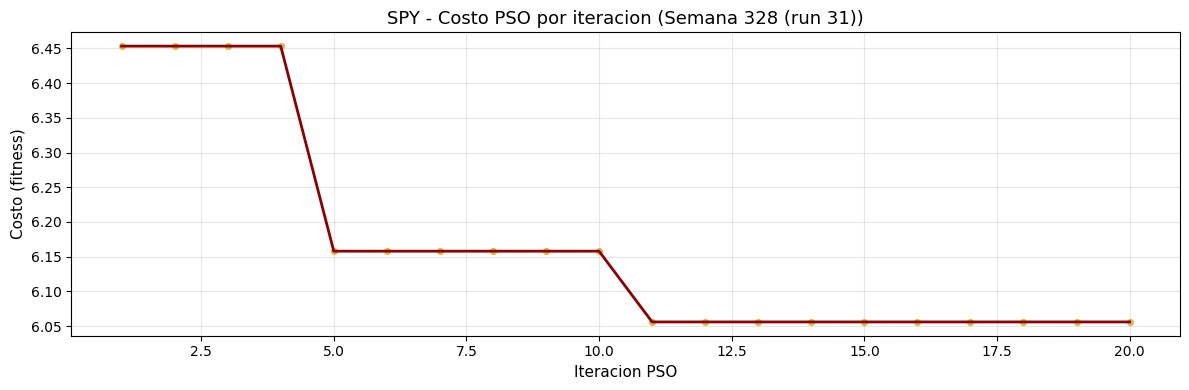

In [76]:
def plot_pso_single_run_cost(ticker, results, run_index=-1):
    pso_cost_history = results.get("pso_cost_history", [])
    pso_run_indices = results.get("pso_run_indices", [])
    if run_index < 0:
        run_index = len(pso_cost_history) + run_index

    costs = numpy.array(pso_cost_history[run_index], dtype=float)
    iters = numpy.arange(1, len(costs) + 1)
    run_label = f"Run {run_index + 1}"
    if len(pso_run_indices) > run_index:
        run_label = f"Semana {pso_run_indices[run_index]} (run {run_index + 1})"

    matplotlib.pyplot.figure(figsize=(12, 4))
    matplotlib.pyplot.plot(iters, costs, color="darkred", linewidth=2)
    matplotlib.pyplot.scatter(iters, costs, color="goldenrod", s=18, alpha=0.7)
    matplotlib.pyplot.title(f"{ticker} - Costo PSO por iteracion ({run_label})", fontsize=13)
    matplotlib.pyplot.xlabel("Iteracion PSO", fontsize=11)
    matplotlib.pyplot.ylabel("Costo (fitness)", fontsize=11)
    matplotlib.pyplot.grid(True, alpha=0.3)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

for ticker in TICKERS:
    plot_pso_single_run_cost(ticker, results[ticker], run_index=30)